In [11]:
import sqlite3
import pandas as pd

# 1. Baca file CSV
df = pd.read_csv("FraudShield_Banking_Data.csv")

# 2. Koneksi ke database SQLite
conn = sqlite3.connect("fraud.db")

# 3. Simpan ke tabel SQL
df.to_sql("transactions", conn, if_exists="replace", index=False)

# 4. Cek isi data (opsional)
query = "SELECT * FROM transactions LIMIT 5;"
result = pd.read_sql(query, conn)
print(result)

# 5. Tutup koneksi
conn.close()

   Transaction_ID  Customer_ID  Transaction_Amount (in Million)  \
0        431438.0      24239.0                              6.0   
1        902451.0      77250.0                              9.0   
2        223410.0      34294.0                              3.0   
3        145626.0      92041.0                              1.0   
4        414637.0      71578.0                              1.0   

  Transaction_Time Transaction_Date Transaction_Type  Merchant_ID  \
0            10:54       2025-03-08              POS      97028.0   
1            19:23       2025-01-17              ATM      27515.0   
2            10:20       2025-04-30              POS      13810.0   
3            14:11       2025-02-21           Online      10501.0   
4            04:12       2025-04-11           Online      53569.0   

  Merchant_Category Transaction_Location Customer_Home_Location  ...  \
0               ATM            Singapore                 Lahore  ...   
1               ATM            Singapo

### STEP 1 : Data Validation

In [18]:
import pandas as pd
import sqlite3

# connect ke database
conn = sqlite3.connect("fraud.db")

# ================================
# 1.1 Total Row Count
# ================================
print("=== Total Rows ===")
query = "SELECT COUNT(*) AS total_rows FROM transactions;"
print(pd.read_sql(query, conn))

=== Total Rows ===
   total_rows
0       50000


In [26]:
query = "PRAGMA table_info(transactions);"
print(pd.read_sql(query, conn))

    cid                                   name  type  notnull dflt_value  pk
0     0                         Transaction_ID  REAL        0       None   0
1     1                            Customer_ID  REAL        0       None   0
2     2        Transaction_Amount (in Million)  REAL        0       None   0
3     3                       Transaction_Time  TEXT        0       None   0
4     4                       Transaction_Date  TEXT        0       None   0
5     5                       Transaction_Type  TEXT        0       None   0
6     6                            Merchant_ID  REAL        0       None   0
7     7                      Merchant_Category  TEXT        0       None   0
8     8                   Transaction_Location  TEXT        0       None   0
9     9                 Customer_Home_Location  TEXT        0       None   0
10   10                     Distance_From_Home  REAL        0       None   0
11   11                              Device_ID  REAL        0       None   0

In [28]:
import sqlite3

conn = sqlite3.connect("fraud.db")
cursor = conn.cursor()

# Rename kolom satu per satu
cursor.execute('ALTER TABLE transactions RENAME COLUMN "Transaction_ID" TO transaction_id;')
cursor.execute('ALTER TABLE transactions RENAME COLUMN "Customer_ID" TO customer_id;')
cursor.execute('ALTER TABLE transactions RENAME COLUMN "Transaction_Amount (in Million)" TO transaction_amount_in_million;')
cursor.execute('ALTER TABLE transactions RENAME COLUMN "Transaction_Time" TO transaction_time;')
cursor.execute('ALTER TABLE transactions RENAME COLUMN "Transaction_Date" TO transaction_date;')
cursor.execute('ALTER TABLE transactions RENAME COLUMN "Transaction_Type" TO transaction_type;')
cursor.execute('ALTER TABLE transactions RENAME COLUMN "Merchant_ID" TO merchant_id;')
cursor.execute('ALTER TABLE transactions RENAME COLUMN "Merchant_Category" TO merchant_category;')
cursor.execute('ALTER TABLE transactions RENAME COLUMN "Transaction_Location" TO transaction_location;')
cursor.execute('ALTER TABLE transactions RENAME COLUMN "Customer_Home_Location" TO customer_home_location;')
cursor.execute('ALTER TABLE transactions RENAME COLUMN "Distance_From_Home" TO distance_from_home;')
cursor.execute('ALTER TABLE transactions RENAME COLUMN "Device_ID" TO device_id;')
cursor.execute('ALTER TABLE transactions RENAME COLUMN "IP_Address" TO ip_address;')
cursor.execute('ALTER TABLE transactions RENAME COLUMN "Card_Type" TO card_type;')
cursor.execute('ALTER TABLE transactions RENAME COLUMN "Account_Balance (in Million)" TO account_balance_in_million;')
cursor.execute('ALTER TABLE transactions RENAME COLUMN "Daily_Transaction_Count" TO daily_transaction_count;')
cursor.execute('ALTER TABLE transactions RENAME COLUMN "Weekly_Transaction_Count" TO weekly_transaction_count;')
cursor.execute('ALTER TABLE transactions RENAME COLUMN "Avg_Transaction_Amount (in Million)" TO avg_transaction_amount_in_million;')
cursor.execute('ALTER TABLE transactions RENAME COLUMN "Max_Transaction_Last_24h (in Million)" TO max_transaction_last_24h_in_million;')
cursor.execute('ALTER TABLE transactions RENAME COLUMN "Is_International_Transaction" TO is_international_transaction;')
cursor.execute('ALTER TABLE transactions RENAME COLUMN "Is_New_Merchant" TO is_new_merchant;')
cursor.execute('ALTER TABLE transactions RENAME COLUMN "Failed_Transaction_Count" TO failed_transaction_count;')
cursor.execute('ALTER TABLE transactions RENAME COLUMN "Unusual_Time_Transaction" TO unusual_time_transaction;')
cursor.execute('ALTER TABLE transactions RENAME COLUMN "Previous_Fraud_Count" TO previous_fraud_count;')
cursor.execute('ALTER TABLE transactions RENAME COLUMN "Fraud_Label" TO fraud_label;')

conn.commit()

print("✅ Semua kolom berhasil direname")

✅ Semua kolom berhasil direname


In [32]:
conn = sqlite3.connect("fraud.db")

print(pd.read_sql(query, conn))

   null_transaction_id  null_customer_id  null_amount  null_date  \
0                    3                10            9          3   

   null_fraud_label  null_card_type  
0                 4               3  


In [34]:
import pandas as pd
import sqlite3

# Load data
df = pd.read_csv("FraudShield_Banking_Data.csv")

# Rename kolom biar SQL-friendly
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)

print(df.columns)  # cek hasil

Index(['transaction_id', 'customer_id', 'transaction_amount_in_million',
       'transaction_time', 'transaction_date', 'transaction_type',
       'merchant_id', 'merchant_category', 'transaction_location',
       'customer_home_location', 'distance_from_home', 'device_id',
       'ip_address', 'card_type', 'account_balance_in_million',
       'daily_transaction_count', 'weekly_transaction_count',
       'avg_transaction_amount_in_million',
       'max_transaction_last_24h_in_million', 'is_international_transaction',
       'is_new_merchant', 'failed_transaction_count',
       'unusual_time_transaction', 'previous_fraud_count', 'fraud_label'],
      dtype='str')


In [36]:
# ================================
# 1.2 Check NULL Values
# ================================
print("\n=== NULL Check ===")
query = """
SELECT
    SUM(CASE WHEN transaction_id IS NULL THEN 1 ELSE 0 END) AS null_transaction_id,
    SUM(CASE WHEN customer_id IS NULL THEN 1 ELSE 0 END) AS null_customer_id,
    SUM(CASE WHEN transaction_amount_in_million IS NULL THEN 1 ELSE 0 END) AS null_amount,
    SUM(CASE WHEN transaction_date IS NULL THEN 1 ELSE 0 END) AS null_date,
    SUM(CASE WHEN fraud_label IS NULL THEN 1 ELSE 0 END) AS null_fraud_label,
    SUM(CASE WHEN card_type IS NULL THEN 1 ELSE 0 END) AS null_card_type
FROM transactions;
"""
print(pd.read_sql(query, conn))


=== NULL Check ===
   null_transaction_id  null_customer_id  null_amount  null_date  \
0                    3                10            9          3   

   null_fraud_label  null_card_type  
0                 4               3  


In [38]:
# ================================
# 1.3 Duplicate Transaction ID
# ================================
print("\n=== Duplicate Transaction ID ===")
query = """
SELECT transaction_id, COUNT(*) AS occurrences
FROM transactions
GROUP BY transaction_id
HAVING COUNT(*) > 1
ORDER BY occurrences DESC;
"""
print(pd.read_sql(query, conn))


=== Duplicate Transaction ID ===
      transaction_id  occurrences
0           931540.0            3
1           852590.0            3
2           846760.0            3
3           839324.0            3
4           808227.0            3
...              ...          ...
1331        102109.0            2
1332        100973.0            2
1333        100583.0            2
1334        100370.0            2
1335        100056.0            2

[1336 rows x 2 columns]


In [40]:
# ================================
# 1.4 Date Range Validation
# ================================
print("\n=== Date Range ===")
query = """
SELECT
    MIN(transaction_date) AS earliest_date,
    MAX(transaction_date) AS latest_date,
    COUNT(DISTINCT transaction_date) AS unique_dates
FROM transactions;
"""
print(pd.read_sql(query, conn))


=== Date Range ===
  earliest_date latest_date  unique_dates
0    2025-01-01  2025-05-01           121


In [42]:
# ================================
# 1.5 Fraud Label Check
# ================================
print("\n=== Fraud Label Distribution ===")
query = """
SELECT fraud_label, COUNT(*) AS count
FROM transactions
GROUP BY fraud_label;
"""
print(pd.read_sql(query, conn))


=== Fraud Label Distribution ===
  fraud_label  count
0         NaN      4
1       Fraud   2423
2      Normal  47573


In [44]:
# ================================
# 1.6 Transaction Type Check
# ================================
print("\n=== Transaction Type Distribution ===")
query = """
SELECT transaction_type, COUNT(*) AS count
FROM transactions
GROUP BY transaction_type
ORDER BY count DESC;
"""
print(pd.read_sql(query, conn))


=== Transaction Type Distribution ===
  transaction_type  count
0           Online  16713
1              ATM  16682
2              POS  16601
3              NaN      4


In [46]:
# ================================
# 1.7 Amount Statistics
# (SQLite tidak support STDDEV ⚠️)
# ================================
print("\n=== Amount Statistics ===")
query = """
SELECT
    MIN(transaction_amount_in_million) AS min_amount,
    MAX(transaction_amount_in_million) AS max_amount,
    AVG(transaction_amount_in_million) AS avg_amount
FROM transactions;
"""
print(pd.read_sql(query, conn))


# OPTIONAL: hitung STDDEV pakai Python
print("\n=== STD DEV (via Python) ===")
df_amount = pd.read_sql("SELECT transaction_amount_in_million FROM transactions", conn)
print("STD DEV:", df_amount["transaction_amount_in_million"].std())


=== Amount Statistics ===
   min_amount  max_amount  avg_amount
0         1.0         9.0     4.99988

=== STD DEV (via Python) ===
STD DEV: 2.582025049504489


### STEP 2 : Data Cleansing

In [49]:
conn = sqlite3.connect("fraud.db")
cursor = conn.cursor()

In [51]:
median_val = pd.read_sql(
    "SELECT transaction_amount_in_million FROM transactions",
    conn
)["transaction_amount_in_million"].median()

cursor.execute("""
UPDATE transactions
SET transaction_amount_in_million = ?
WHERE transaction_amount_in_million IS NULL;
""", (median_val,))

conn.commit()

In [53]:
cursor.execute("""
UPDATE transactions
SET fraud_label = 'Normal'
WHERE fraud_label IS NULL;
""")
conn.commit()

In [55]:
query = """
SELECT card_type
FROM transactions
WHERE card_type IS NOT NULL
GROUP BY card_type
ORDER BY COUNT(*) DESC
LIMIT 1;
"""
most_card = pd.read_sql(query, conn).iloc[0, 0]

cursor.execute("""
UPDATE transactions
SET card_type = ?
WHERE card_type IS NULL;
""", (most_card,))

conn.commit()

In [57]:
query = """
SELECT transaction_type
FROM transactions
WHERE transaction_type IS NOT NULL
GROUP BY transaction_type
ORDER BY COUNT(*) DESC
LIMIT 1;
"""
most_txn = pd.read_sql(query, conn).iloc[0, 0]

cursor.execute("""
UPDATE transactions
SET transaction_type = ?
WHERE transaction_type IS NULL;
""", (most_txn,))

conn.commit()

In [59]:
cursor.execute("ALTER TABLE transactions ADD COLUMN txn_month TEXT;")

cursor.execute("""
UPDATE transactions
SET txn_month = substr(transaction_date, 1, 7);
""")

conn.commit()

In [61]:
cursor.execute("ALTER TABLE transactions ADD COLUMN is_home_location TEXT;")

cursor.execute("""
UPDATE transactions
SET is_home_location =
    CASE
        WHEN transaction_location = customer_home_location THEN 'Yes'
        ELSE 'No'
    END;
""")

conn.commit()

In [63]:
cursor.execute("ALTER TABLE transactions ADD COLUMN risk_score INTEGER DEFAULT 0;")

cursor.execute("""
UPDATE transactions
SET risk_score =
    (CASE WHEN is_international_transaction = 'Yes' THEN 1 ELSE 0 END) +
    (CASE WHEN is_new_merchant = 'Yes' THEN 1 ELSE 0 END) +
    (CASE WHEN unusual_time_transaction = 'Yes' THEN 1 ELSE 0 END) +
    (CASE WHEN failed_transaction_count > 0 THEN 1 ELSE 0 END) +
    (CASE WHEN previous_fraud_count > 0 THEN 1 ELSE 0 END) +
    (CASE WHEN distance_from_home > 400 THEN 1 ELSE 0 END);
""")

conn.commit()

In [67]:
cursor.execute("""
UPDATE transactions
SET risk_score =
    (CASE WHEN is_international_transaction = 'Yes' THEN 1 ELSE 0 END) +
    (CASE WHEN is_new_merchant = 'Yes' THEN 1 ELSE 0 END) +
    (CASE WHEN unusual_time_transaction = 'Yes' THEN 1 ELSE 0 END) +
    (CASE WHEN failed_transaction_count > 0 THEN 1 ELSE 0 END) +
    (CASE WHEN previous_fraud_count > 0 THEN 1 ELSE 0 END) +
    (CASE WHEN distance_from_home > 400 THEN 1 ELSE 0 END);
""")

conn.commit()

### 2.1 Overview KPIs

In [70]:
print("=== EXECUTIVE SUMMARY KPI ===")

query = """
SELECT
    COUNT(*) AS total_transactions,
    COUNT(DISTINCT customer_id) AS unique_customers,
    COUNT(DISTINCT merchant_id) AS unique_merchants,
    ROUND(SUM(transaction_amount_in_million), 2) AS total_amount_M,
    ROUND(AVG(transaction_amount_in_million), 2) AS avg_amount_M,
    SUM(CASE WHEN fraud_label = 'Fraud' THEN 1 ELSE 0 END) AS total_fraud_cases,
    SUM(CASE WHEN fraud_label = 'Normal' THEN 1 ELSE 0 END) AS total_normal_cases,
    ROUND(
        SUM(CASE WHEN fraud_label = 'Fraud' THEN 1.0 ELSE 0 END) * 100.0
        / COUNT(*), 2
    ) AS fraud_rate_pct
FROM transactions;
"""

print(pd.read_sql(query, conn))

=== EXECUTIVE SUMMARY KPI ===
   total_transactions  unique_customers  unique_merchants  total_amount_M  \
0               50000             38353             38314        249994.0   

   avg_amount_M  total_fraud_cases  total_normal_cases  fraud_rate_pct  
0           5.0               2423               47577            4.85  


In [72]:
print("\n=== FRAUD VS NORMAL SUMMARY ===")

query = """
SELECT
    fraud_label,
    COUNT(*) AS transaction_count,
    ROUND(
        COUNT(*) * 100.0 /
        (SELECT COUNT(*) FROM transactions), 2
    ) AS pct_of_total,
    ROUND(AVG(transaction_amount_in_million), 2) AS avg_amount_M,
    ROUND(SUM(transaction_amount_in_million), 2) AS total_amount_M
FROM transactions
GROUP BY fraud_label;
"""

print(pd.read_sql(query, conn))


=== FRAUD VS NORMAL SUMMARY ===
  fraud_label  transaction_count  pct_of_total  avg_amount_M  total_amount_M
0       Fraud               2423          4.85          4.99         12086.0
1      Normal              47577         95.15          5.00        237908.0


### STEP 3 : Time-series Analysis

In [75]:
print("=== MONTHLY TREND ===")

query = """
SELECT
    txn_month AS month,
    COUNT(*) AS total_transactions,
    SUM(CASE WHEN fraud_label = 'Fraud' THEN 1 ELSE 0 END) AS fraud_count,
    ROUND(
        SUM(CASE WHEN fraud_label = 'Fraud' THEN 1.0 ELSE 0 END) * 100.0
        / COUNT(*), 2
    ) AS fraud_rate_pct,
    ROUND(SUM(transaction_amount_in_million), 2) AS total_amount_M,
    ROUND(AVG(transaction_amount_in_million), 2) AS avg_amount_M
FROM transactions
GROUP BY txn_month
ORDER BY txn_month;
"""

print(pd.read_sql(query, conn))

=== MONTHLY TREND ===
     month  total_transactions  fraud_count  fraud_rate_pct  total_amount_M  \
0      NaN                   3            0            0.00            11.0   
1  2025-01               12691          631            4.97         63203.0   
2  2025-02               11585          582            5.02         58481.0   
3  2025-03               12849          596            4.64         64087.0   
4  2025-04               12459          598            4.80         62109.0   
5  2025-05                 413           16            3.87          2103.0   

   avg_amount_M  
0          3.67  
1          4.98  
2          5.05  
3          4.99  
4          4.99  
5          5.09  


In [77]:
print("\n=== TOP 15 PEAK FRAUD DAYS ===")

query = """
SELECT
    transaction_date,
    COUNT(*) AS total_transactions,
    SUM(CASE WHEN fraud_label = 'Fraud' THEN 1 ELSE 0 END) AS fraud_count,
    ROUND(
        SUM(CASE WHEN fraud_label = 'Fraud' THEN 1.0 ELSE 0 END) * 100.0
        / COUNT(*), 2
    ) AS fraud_rate_pct
FROM transactions
GROUP BY transaction_date
ORDER BY fraud_count DESC
LIMIT 15;
"""

print(pd.read_sql(query, conn))


=== TOP 15 PEAK FRAUD DAYS ===
   transaction_date  total_transactions  fraud_count  fraud_rate_pct
0        2025-04-27                 430           29            6.74
1        2025-03-28                 422           28            6.64
2        2025-02-18                 412           28            6.80
3        2025-02-12                 406           28            6.90
4        2025-03-23                 416           27            6.49
5        2025-02-05                 446           27            6.05
6        2025-01-09                 395           27            6.84
7        2025-01-01                 394           27            6.85
8        2025-03-31                 429           26            6.06
9        2025-02-28                 407           26            6.39
10       2025-02-23                 371           26            7.01
11       2025-01-05                 416           26            6.25
12       2025-04-14                 440           25            5.68
13

In [79]:
print("\n=== HOURLY FRAUD PATTERN ===")

query = """
SELECT
    SUBSTR(transaction_time, 1, 2) AS hour_of_day,
    COUNT(*) AS total_transactions,
    SUM(CASE WHEN fraud_label = 'Fraud' THEN 1 ELSE 0 END) AS fraud_count,
    ROUND(
        SUM(CASE WHEN fraud_label = 'Fraud' THEN 1.0 ELSE 0 END) * 100.0
        / COUNT(*), 2
    ) AS fraud_rate_pct
FROM transactions
WHERE transaction_time IS NOT NULL
GROUP BY SUBSTR(transaction_time, 1, 2)
ORDER BY hour_of_day;
"""

print(pd.read_sql(query, conn))


=== HOURLY FRAUD PATTERN ===
   hour_of_day  total_transactions  fraud_count  fraud_rate_pct
0           00                2029           93            4.58
1           01                2069           81            3.91
2           02                2059          107            5.20
3           03                2144          100            4.66
4           04                2011           86            4.28
5           05                2137          103            4.82
6           06                2104           81            3.85
7           07                2161          113            5.23
8           08                2032          107            5.27
9           09                2058          105            5.10
10          10                2067          100            4.84
11          11                2088          102            4.89
12          12                2147          109            5.08
13          13                2081          114            5.48
14        

### STEP 4 : Fraud Pattern Analysis

In [82]:
print("=== FRAUD BY TRANSACTION TYPE ===")

query = """
SELECT
    transaction_type,
    COUNT(*) AS total,
    SUM(CASE WHEN fraud_label = 'Fraud' THEN 1 ELSE 0 END) AS fraud_count,
    ROUND(
        SUM(CASE WHEN fraud_label = 'Fraud' THEN 1.0 ELSE 0 END) * 100.0
        / COUNT(*), 2
    ) AS fraud_rate_pct,
    ROUND(AVG(transaction_amount_in_million), 2) AS avg_amount_M
FROM transactions
WHERE transaction_type IS NOT NULL
GROUP BY transaction_type
ORDER BY fraud_rate_pct DESC;
"""

print(pd.read_sql(query, conn))

=== FRAUD BY TRANSACTION TYPE ===
  transaction_type  total  fraud_count  fraud_rate_pct  avg_amount_M
0           Online  16717          843            5.04           5.0
1              ATM  16682          797            4.78           5.0
2              POS  16601          783            4.72           5.0


In [84]:
print("\n=== FRAUD BY MERCHANT CATEGORY ===")

query = """
SELECT
    merchant_category,
    COUNT(*) AS total_transactions,
    SUM(CASE WHEN fraud_label = 'Fraud' THEN 1 ELSE 0 END) AS fraud_count,
    ROUND(
        SUM(CASE WHEN fraud_label = 'Fraud' THEN 1.0 ELSE 0 END) * 100.0
        / COUNT(*), 2
    ) AS fraud_rate_pct
FROM transactions
WHERE merchant_category IS NOT NULL
GROUP BY merchant_category
ORDER BY fraud_rate_pct DESC;
"""

print(pd.read_sql(query, conn))


=== FRAUD BY MERCHANT CATEGORY ===
  merchant_category  total_transactions  fraud_count  fraud_rate_pct
0        Restaurant                8483          427            5.03
1               ATM                8401          421            5.01
2              Fuel                8358          408            4.88
3           Grocery                8252          397            4.81
4       Electronics                8216          389            4.73
5          Clothing                8281          380            4.59


In [86]:
print("\n=== INTERNATIONAL VS DOMESTIC FRAUD ===")

query = """
SELECT
    is_international_transaction AS international,
    COUNT(*) AS total,
    SUM(CASE WHEN fraud_label = 'Fraud' THEN 1 ELSE 0 END) AS fraud_count,
    ROUND(
        SUM(CASE WHEN fraud_label = 'Fraud' THEN 1.0 ELSE 0 END) * 100.0
        / COUNT(*), 2
    ) AS fraud_rate_pct,
    ROUND(AVG(transaction_amount_in_million), 2) AS avg_amount_M
FROM transactions
WHERE is_international_transaction IS NOT NULL
GROUP BY is_international_transaction;
"""

print(pd.read_sql(query, conn))


=== INTERNATIONAL VS DOMESTIC FRAUD ===
  international  total  fraud_count  fraud_rate_pct  avg_amount_M
0            No  24934          885            3.55          5.03
1           Yes  25062         1538            6.14          4.97


In [88]:
print("\n=== UNUSUAL TIME FRAUD ===")

query = """
SELECT
    unusual_time_transaction,
    COUNT(*) AS total,
    SUM(CASE WHEN fraud_label = 'Fraud' THEN 1 ELSE 0 END) AS fraud_count,
    ROUND(
        SUM(CASE WHEN fraud_label = 'Fraud' THEN 1.0 ELSE 0 END) * 100.0
        / COUNT(*), 2
    ) AS fraud_rate_pct
FROM transactions
WHERE unusual_time_transaction IS NOT NULL
GROUP BY unusual_time_transaction;
"""

print(pd.read_sql(query, conn))


=== UNUSUAL TIME FRAUD ===
  unusual_time_transaction  total  fraud_count  fraud_rate_pct
0                       No  25111          896            3.57
1                      Yes  24886         1527            6.14


In [90]:
print("\n=== NEW MERCHANT FRAUD ===")

query = """
SELECT
    is_new_merchant,
    COUNT(*) AS total,
    SUM(CASE WHEN fraud_label = 'Fraud' THEN 1 ELSE 0 END) AS fraud_count,
    ROUND(
        SUM(CASE WHEN fraud_label = 'Fraud' THEN 1.0 ELSE 0 END) * 100.0
        / COUNT(*), 2
    ) AS fraud_rate_pct,
    ROUND(AVG(transaction_amount_in_million), 2) AS avg_amount_M
FROM transactions
WHERE is_new_merchant IS NOT NULL
GROUP BY is_new_merchant;
"""

print(pd.read_sql(query, conn))


=== NEW MERCHANT FRAUD ===
  is_new_merchant  total  fraud_count  fraud_rate_pct  avg_amount_M
0              No  24939         1197            4.80          4.99
1             Yes  25056         1226            4.89          5.01


In [92]:
print("\n=== FAILED TRANSACTION VS FRAUD ===")

query = """
SELECT
    failed_transaction_count AS failed_count,
    COUNT(*) AS total,
    SUM(CASE WHEN fraud_label = 'Fraud' THEN 1 ELSE 0 END) AS fraud_count,
    ROUND(
        SUM(CASE WHEN fraud_label = 'Fraud' THEN 1.0 ELSE 0 END) * 100.0
        / COUNT(*), 2
    ) AS fraud_rate_pct
FROM transactions
WHERE failed_transaction_count <= 5
GROUP BY failed_transaction_count
ORDER BY failed_transaction_count;
"""

print(pd.read_sql(query, conn))


=== FAILED TRANSACTION VS FRAUD ===
   failed_count  total  fraud_count  fraud_rate_pct
0           0.0  16827          803            4.77
1           1.0  16695          846            5.07
2           2.0  16467          773            4.69


In [94]:
print("\n=== CARD TYPE FRAUD ===")

query = """
SELECT
    card_type,
    COUNT(*) AS total,
    SUM(CASE WHEN fraud_label = 'Fraud' THEN 1 ELSE 0 END) AS fraud_count,
    ROUND(
        SUM(CASE WHEN fraud_label = 'Fraud' THEN 1.0 ELSE 0 END) * 100.0
        / COUNT(*), 2
    ) AS fraud_rate_pct,
    ROUND(AVG(account_balance_in_million), 2) AS avg_balance_M
FROM transactions
WHERE card_type IS NOT NULL
GROUP BY card_type
ORDER BY fraud_rate_pct DESC;
"""

print(pd.read_sql(query, conn))


=== CARD TYPE FRAUD ===
  card_type  total  fraud_count  fraud_rate_pct  avg_balance_M
0    Credit  24891         1216            4.89          20.97
1     Debit  25109         1207            4.81          21.02


### STEP 5 : Geographic & Distance Analysis

In [100]:
print("=== FRAUD BY LOCATION ===")

query = """
SELECT
    transaction_location,
    COUNT(*) AS total_transactions,
    SUM(CASE WHEN fraud_label = 'Fraud' THEN 1 ELSE 0 END) AS fraud_count,
    ROUND(
        SUM(CASE WHEN fraud_label = 'Fraud' THEN 1.0 ELSE 0 END) * 100.0
        / COUNT(*), 2
    ) AS fraud_rate_pct,
    ROUND(AVG(distance_from_home), 1) AS avg_distance_km
FROM transactions
GROUP BY transaction_location
ORDER BY fraud_rate_pct DESC;
"""

print(pd.read_sql(query, conn))

=== FRAUD BY LOCATION ===
   transaction_location  total_transactions  fraud_count  fraud_rate_pct  \
0             Singapore                5025          256            5.09   
1               Bangkok                4986          253            5.07   
2                London                4896          241            4.92   
3            Faisalabad                5017          246            4.90   
4          Kuala Lumpur                5071          247            4.87   
5                Lahore                5050          245            4.85   
6                 Dubai                4916          238            4.84   
7                Multan                5083          244            4.80   
8             Islamabad                5019          230            4.58   
9               Karachi                4931          223            4.52   
10                  NaN                   6            0            0.00   

    avg_distance_km  
0             305.9  
1             295

In [102]:
print("\n=== DISTANCE BUCKET FRAUD ===")

query = """
SELECT
    CASE
        WHEN distance_from_home < 100 THEN '1. < 100 km'
        WHEN distance_from_home < 200 THEN '2. 100-200 km'
        WHEN distance_from_home < 300 THEN '3. 200-300 km'
        WHEN distance_from_home < 400 THEN '4. 300-400 km'
        ELSE '5. > 400 km'
    END AS distance_bucket,
    COUNT(*) AS total,
    SUM(CASE WHEN fraud_label = 'Fraud' THEN 1 ELSE 0 END) AS fraud_count,
    ROUND(
        SUM(CASE WHEN fraud_label = 'Fraud' THEN 1.0 ELSE 0 END) * 100.0
        / COUNT(*), 2
    ) AS fraud_rate_pct
FROM transactions
GROUP BY distance_bucket
ORDER BY distance_bucket;
"""

print(pd.read_sql(query, conn))


=== DISTANCE BUCKET FRAUD ===
  distance_bucket  total  fraud_count  fraud_rate_pct
0     1. < 100 km   8290          445            5.37
1   2. 100-200 km   8288          403            4.86
2   3. 200-300 km   8318          403            4.84
3   4. 300-400 km   8378          391            4.67
4     5. > 400 km  16726          781            4.67


In [104]:
print("\n=== HOME VS AWAY FRAUD ===")

query = """
SELECT
    is_home_location,
    COUNT(*) AS total,
    SUM(CASE WHEN fraud_label = 'Fraud' THEN 1 ELSE 0 END) AS fraud_count,
    ROUND(
        SUM(CASE WHEN fraud_label = 'Fraud' THEN 1.0 ELSE 0 END) * 100.0
        / COUNT(*), 2
    ) AS fraud_rate_pct
FROM transactions
GROUP BY is_home_location;
"""

print(pd.read_sql(query, conn))


=== HOME VS AWAY FRAUD ===
  is_home_location  total  fraud_count  fraud_rate_pct
0               No  44943         2199            4.89
1              Yes   5057          224            4.43


### STEP 6 : Customer Risk Profiling

In [107]:
print("=== TOP 10 HIGH-RISK CUSTOMERS ===")

query = """
SELECT
    customer_id,
    COUNT(*) AS total_transactions,
    SUM(CASE WHEN fraud_label = 'Fraud' THEN 1 ELSE 0 END) AS fraud_count,
    ROUND(
        SUM(CASE WHEN fraud_label = 'Fraud' THEN 1.0 ELSE 0 END) * 100.0
        / COUNT(*), 2
    ) AS personal_fraud_rate_pct,
    ROUND(MAX(previous_fraud_count), 0) AS max_prev_fraud,
    ROUND(AVG(transaction_amount_in_million), 2) AS avg_amount_M,
    ROUND(AVG(failed_transaction_count), 2) AS avg_failed_txn
FROM transactions
GROUP BY customer_id
HAVING fraud_count > 0
ORDER BY fraud_count DESC, max_prev_fraud DESC
LIMIT 10;
"""

print(pd.read_sql(query, conn))

=== TOP 10 HIGH-RISK CUSTOMERS ===
   customer_id  total_transactions  fraud_count  personal_fraud_rate_pct  \
0      41045.0                   3            3                   100.00   
1      10412.0                   3            2                    66.67   
2      11835.0                   2            2                   100.00   
3      14975.0                   2            2                   100.00   
4      18469.0                   3            2                    66.67   
5      22972.0                   2            2                   100.00   
6      28583.0                   3            2                    66.67   
7      30443.0                   2            2                   100.00   
8      30756.0                   2            2                   100.00   
9      37283.0                   2            2                   100.00   

   max_prev_fraud  avg_amount_M  avg_failed_txn  
0             1.0          4.33            1.00  
1             1.0          4

In [109]:
print("\n=== HIGH VALUE + FRAUD CUSTOMERS ===")

query = """
SELECT
    customer_id,
    COUNT(*) AS txn_count,
    ROUND(AVG(transaction_amount_in_million), 2) AS personal_avg_M,
    ROUND((SELECT AVG(transaction_amount_in_million) FROM transactions), 2) AS global_avg_M,
    ROUND(
        AVG(transaction_amount_in_million)
        - (SELECT AVG(transaction_amount_in_million) FROM transactions), 2
    ) AS diff_from_global_avg,
    SUM(CASE WHEN fraud_label = 'Fraud' THEN 1 ELSE 0 END) AS fraud_count
FROM transactions
GROUP BY customer_id
HAVING personal_avg_M > (SELECT AVG(transaction_amount_in_million) FROM transactions)
   AND fraud_count > 0
ORDER BY fraud_count DESC, diff_from_global_avg DESC
LIMIT 10;
"""

print(pd.read_sql(query, conn))


=== HIGH VALUE + FRAUD CUSTOMERS ===
   customer_id  txn_count  personal_avg_M  global_avg_M  diff_from_global_avg  \
0      38946.0          2            7.00           5.0                  2.00   
1      41816.0          2            7.00           5.0                  2.00   
2      29076.0          2            6.50           5.0                  1.50   
3      37283.0          2            6.50           5.0                  1.50   
4      42350.0          2            6.50           5.0                  1.50   
5      11835.0          2            6.00           5.0                  1.00   
6      57251.0          3            5.67           5.0                  0.67   
7      51398.0          2            5.50           5.0                  0.50   
8      67878.0          4            5.50           5.0                  0.50   
9      81043.0          2            5.50           5.0                  0.50   

   fraud_count  
0            2  
1            2  
2            2  
3 

In [111]:
print("\n=== RISK SCORE SEGMENTATION ===")

query = """
SELECT
    risk_score,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN fraud_label = 'Fraud' THEN 1 ELSE 0 END) AS fraud_count,
    ROUND(
        SUM(CASE WHEN fraud_label = 'Fraud' THEN 1.0 ELSE 0 END) * 100.0
        / COUNT(*), 2
    ) AS fraud_rate_pct,
    ROUND(AVG(transaction_amount_in_million), 2) AS avg_amount_M
FROM transactions
GROUP BY risk_score
ORDER BY risk_score;
"""

print(pd.read_sql(query, conn))


=== RISK SCORE SEGMENTATION ===
   risk_score  total_customers  fraud_count  fraud_rate_pct  avg_amount_M
0           0              694           13            1.87          4.88
1           1             4470          136            3.04          5.03
2           2            11989          474            3.95          4.99
3           3            15928          754            4.73          4.99
4           4            11721          709            6.05          5.03
5           5             4504          280            6.22          4.99
6           6              694           57            8.21          4.94


In [113]:
print("\n=== REPEAT FRAUD CUSTOMERS ===")

query = """
SELECT
    customer_id,
    SUM(CASE WHEN fraud_label = 'Fraud' THEN 1 ELSE 0 END) AS current_fraud_count,
    MAX(previous_fraud_count) AS previous_fraud_count,
    ROUND(AVG(account_balance_in_million), 2) AS avg_balance_M,
    GROUP_CONCAT(DISTINCT transaction_location) AS locations_used
FROM transactions
WHERE previous_fraud_count > 1
GROUP BY customer_id
HAVING current_fraud_count > 0
ORDER BY current_fraud_count DESC
LIMIT 15;
"""

print(pd.read_sql(query, conn))


=== REPEAT FRAUD CUSTOMERS ===
Empty DataFrame
Columns: [customer_id, current_fraud_count, previous_fraud_count, avg_balance_M, locations_used]
Index: []


### STEP 7 : Merchant Risk Analysis

In [116]:
print("=== TOP FRAUD-PRONE MERCHANTS ===")

query = """
SELECT
    merchant_id,
    merchant_category,
    COUNT(*) AS total_transactions,
    SUM(CASE WHEN fraud_label = 'Fraud' THEN 1 ELSE 0 END) AS fraud_count,
    ROUND(
        SUM(CASE WHEN fraud_label = 'Fraud' THEN 1.0 ELSE 0 END) * 100.0
        / COUNT(*), 2
    ) AS fraud_rate_pct,
    ROUND(AVG(transaction_amount_in_million), 2) AS avg_txn_amount_M
FROM transactions
GROUP BY merchant_id, merchant_category
HAVING COUNT(*) >= 3
ORDER BY fraud_rate_pct DESC, fraud_count DESC
LIMIT 20;
"""

print(pd.read_sql(query, conn))

=== TOP FRAUD-PRONE MERCHANTS ===
    merchant_id merchant_category  total_transactions  fraud_count  \
0       79424.0               ATM                   3            2   
1       99800.0               ATM                   3            1   
2       93359.0          Clothing                   3            1   
3       85763.0       Electronics                   3            1   
4       74761.0       Electronics                   3            1   
5       73801.0        Restaurant                   3            1   
6       72436.0       Electronics                   3            1   
7       69900.0              Fuel                   3            1   
8       67430.0               ATM                   3            1   
9       52226.0       Electronics                   3            1   
10      20914.0        Restaurant                   3            1   
11      15271.0               ATM                   3            1   
12      51261.0           Grocery                   4   

In [118]:
print("\n=== MERCHANT CATEGORY PERFORMANCE ===")

query = """
SELECT
    merchant_category,
    COUNT(*) AS total_transactions,
    COUNT(DISTINCT merchant_id) AS unique_merchants,
    SUM(CASE WHEN fraud_label = 'Fraud' THEN 1 ELSE 0 END) AS fraud_count,
    ROUND(
        SUM(CASE WHEN fraud_label = 'Fraud' THEN 1.0 ELSE 0 END) * 100.0
        / COUNT(*), 2
    ) AS fraud_rate_pct,
    ROUND(AVG(transaction_amount_in_million), 2) AS avg_amount_M,
    ROUND(SUM(transaction_amount_in_million), 2) AS total_amount_M
FROM transactions
WHERE merchant_category IS NOT NULL
GROUP BY merchant_category
ORDER BY total_amount_M DESC;
"""

print(pd.read_sql(query, conn))


=== MERCHANT CATEGORY PERFORMANCE ===
  merchant_category  total_transactions  unique_merchants  fraud_count  \
0        Restaurant                8483              8079          427   
1               ATM                8401              8030          421   
2              Fuel                8358              8009          408   
3          Clothing                8281              7928          380   
4           Grocery                8252              7896          397   
5       Electronics                8216              7821          389   

   fraud_rate_pct  avg_amount_M  total_amount_M  
0            5.03          5.01         42496.0  
1            5.01          5.00         42025.0  
2            4.88          5.00         41754.0  
3            4.59          5.01         41460.0  
4            4.81          5.02         41408.0  
5            4.73          4.97         40808.0  


### STEP 8 : Multi-Factor Analysis

In [121]:
print("=== MULTI-FACTOR HIGH RISK ===")

query = """
SELECT
    COUNT(*) AS high_risk_transactions,
    SUM(CASE WHEN fraud_label = 'Fraud' THEN 1 ELSE 0 END) AS confirmed_fraud,
    ROUND(
        SUM(CASE WHEN fraud_label = 'Fraud' THEN 1.0 ELSE 0 END) * 100.0
        / COUNT(*), 2
    ) AS fraud_rate_pct,
    ROUND(AVG(transaction_amount_in_million), 2) AS avg_amount_M
FROM transactions
WHERE
    is_international_transaction = 'Yes'
    AND is_new_merchant = 'Yes'
    AND unusual_time_transaction = 'Yes'
    AND failed_transaction_count > 0;
"""

print(pd.read_sql(query, conn))

=== MULTI-FACTOR HIGH RISK ===
   high_risk_transactions  confirmed_fraud  fraud_rate_pct  avg_amount_M
0                    4181              314            7.51          5.03


In [123]:
print("\n=== TRANSACTION TYPE × INTERNATIONAL ===")

query = """
SELECT
    transaction_type,
    is_international_transaction AS international,
    COUNT(*) AS total,
    SUM(CASE WHEN fraud_label = 'Fraud' THEN 1 ELSE 0 END) AS fraud_count,
    ROUND(
        SUM(CASE WHEN fraud_label = 'Fraud' THEN 1.0 ELSE 0 END) * 100.0
        / COUNT(*), 2
    ) AS fraud_rate_pct
FROM transactions
WHERE transaction_type IS NOT NULL
  AND is_international_transaction IS NOT NULL
GROUP BY transaction_type, is_international_transaction
ORDER BY fraud_rate_pct DESC;
"""

print(pd.read_sql(query, conn))


=== TRANSACTION TYPE × INTERNATIONAL ===
  transaction_type international  total  fraud_count  fraud_rate_pct
0           Online           Yes   8379          537            6.41
1              ATM           Yes   8320          503            6.05
2              POS           Yes   8363          498            5.95
3           Online            No   8337          306            3.67
4              ATM            No   8359          294            3.52
5              POS            No   8238          285            3.46


In [125]:
print("\n=== RISK SCORE VALIDATION ===")

query = """
SELECT
    risk_score AS risk_flags_count,
    COUNT(*) AS total_transactions,
    SUM(CASE WHEN fraud_label = 'Fraud' THEN 1 ELSE 0 END) AS fraud_count,
    ROUND(
        SUM(CASE WHEN fraud_label = 'Fraud' THEN 1.0 ELSE 0 END) * 100.0
        / COUNT(*), 2
    ) AS fraud_rate_pct,
    ROUND(AVG(transaction_amount_in_million), 2) AS avg_amount_M
FROM transactions
GROUP BY risk_score
ORDER BY risk_score;
"""

print(pd.read_sql(query, conn))


=== RISK SCORE VALIDATION ===
   risk_flags_count  total_transactions  fraud_count  fraud_rate_pct  \
0                 0                 694           13            1.87   
1                 1                4470          136            3.04   
2                 2               11989          474            3.95   
3                 3               15928          754            4.73   
4                 4               11721          709            6.05   
5                 5                4504          280            6.22   
6                 6                 694           57            8.21   

   avg_amount_M  
0          4.88  
1          5.03  
2          4.99  
3          4.99  
4          5.03  
5          4.99  
6          4.94  


In [127]:
print("\n=== FRAUD HISTORY EFFECT ===")

query = """
SELECT
    previous_fraud_count AS prev_fraud_history,
    COUNT(*) AS total_transactions,
    SUM(CASE WHEN fraud_label = 'Fraud' THEN 1 ELSE 0 END) AS current_fraud,
    ROUND(
        SUM(CASE WHEN fraud_label = 'Fraud' THEN 1.0 ELSE 0 END) * 100.0
        / COUNT(*), 2
    ) AS fraud_rate_pct
FROM transactions
GROUP BY previous_fraud_count
ORDER BY previous_fraud_count;
"""

print(pd.read_sql(query, conn))


=== FRAUD HISTORY EFFECT ===
   prev_fraud_history  total_transactions  current_fraud  fraud_rate_pct
0                 NaN                   3              0            0.00
1                 0.0               24992           1185            4.74
2                 1.0               25005           1238            4.95


In [129]:
print("\n=== HIGH VALUE FRAUD ===")

query = """
SELECT
    CASE
        WHEN transaction_amount_in_million >= 8 THEN 'Very High (8-9M)'
        WHEN transaction_amount_in_million >= 6 THEN 'High (6-7M)'
        WHEN transaction_amount_in_million >= 4 THEN 'Medium (4-5M)'
        ELSE 'Low (1-3M)'
    END AS amount_tier,
    COUNT(*) AS total,
    SUM(CASE WHEN fraud_label = 'Fraud' THEN 1 ELSE 0 END) AS fraud_count,
    ROUND(
        SUM(CASE WHEN fraud_label = 'Fraud' THEN 1.0 ELSE 0 END) * 100.0
        / COUNT(*), 2
    ) AS fraud_rate_pct
FROM transactions
GROUP BY amount_tier
ORDER BY MIN(transaction_amount_in_million) DESC;
"""

print(pd.read_sql(query, conn))


=== HIGH VALUE FRAUD ===
        amount_tier  total  fraud_count  fraud_rate_pct
0  Very High (8-9M)  11096          530            4.78
1       High (6-7M)  11102          540            4.86
2     Medium (4-5M)  11095          537            4.84
3        Low (1-3M)  16707          816            4.88


### STEP 9 : Advanced Query

In [132]:
print("=== HIGH FRAUD RATE CUSTOMERS ===")

query = """
SELECT
    customer_id,
    COUNT(*) AS total_txn,
    SUM(CASE WHEN fraud_label = 'Fraud' THEN 1 ELSE 0 END) AS fraud_count,
    ROUND(
        SUM(CASE WHEN fraud_label = 'Fraud' THEN 1.0 ELSE 0 END) * 100.0
        / COUNT(*), 2
    ) AS personal_fraud_rate,
    ROUND(
        (SELECT SUM(CASE WHEN fraud_label = 'Fraud' THEN 1.0 ELSE 0 END)
         / COUNT(*) * 100 FROM transactions), 2
    ) AS global_fraud_rate
FROM transactions
GROUP BY customer_id
HAVING personal_fraud_rate > 2 * (
    SELECT SUM(CASE WHEN fraud_label = 'Fraud' THEN 1.0 ELSE 0 END)
         / COUNT(*) * 100 FROM transactions
)
AND total_txn >= 2
ORDER BY personal_fraud_rate DESC
LIMIT 20;
"""

print(pd.read_sql(query, conn))

=== HIGH FRAUD RATE CUSTOMERS ===
    customer_id  total_txn  fraud_count  personal_fraud_rate  \
0       98943.0          2            2                100.0   
1       93976.0          2            2                100.0   
2       81043.0          2            2                100.0   
3       80614.0          2            2                100.0   
4       72076.0          2            2                100.0   
5       71486.0          2            2                100.0   
6       70345.0          2            2                100.0   
7       56555.0          2            2                100.0   
8       55071.0          2            2                100.0   
9       51398.0          2            2                100.0   
10      45427.0          2            2                100.0   
11      42693.0          2            2                100.0   
12      42350.0          2            2                100.0   
13      41816.0          2            2                100.0   
14    

In [134]:
print("\n=== CUMULATIVE FRAUD TREND ===")

query = """
SELECT
    txn_month,
    fraud_count,
    SUM(fraud_count) OVER (
        ORDER BY txn_month
        ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
    ) AS cumulative_fraud
FROM (
    SELECT
        txn_month,
        SUM(CASE WHEN fraud_label = 'Fraud' THEN 1 ELSE 0 END) AS fraud_count
    FROM transactions
    GROUP BY txn_month
) AS monthly_fraud
ORDER BY txn_month;
"""

print(pd.read_sql(query, conn))


=== CUMULATIVE FRAUD TREND ===
  txn_month  fraud_count  cumulative_fraud
0       NaN            0                 0
1   2025-01          631               631
2   2025-02          582              1213
3   2025-03          596              1809
4   2025-04          598              2407
5   2025-05           16              2423


In [136]:
print("\n=== LOCATION FRAUD RANKING ===")

query = """
SELECT
    transaction_location,
    fraud_count,
    total_transactions,
    fraud_rate_pct,
    RANK() OVER (ORDER BY fraud_count DESC) AS fraud_rank
FROM (
    SELECT
        transaction_location,
        COUNT(*) AS total_transactions,
        SUM(CASE WHEN fraud_label = 'Fraud' THEN 1 ELSE 0 END) AS fraud_count,
        ROUND(
            SUM(CASE WHEN fraud_label = 'Fraud' THEN 1.0 ELSE 0 END) * 100.0
            / COUNT(*), 2
        ) AS fraud_rate_pct
    FROM transactions
    GROUP BY transaction_location
) AS loc_summary;
"""

print(pd.read_sql(query, conn))


=== LOCATION FRAUD RANKING ===
   transaction_location  fraud_count  total_transactions  fraud_rate_pct  \
0             Singapore          256                5025            5.09   
1               Bangkok          253                4986            5.07   
2          Kuala Lumpur          247                5071            4.87   
3            Faisalabad          246                5017            4.90   
4                Lahore          245                5050            4.85   
5                Multan          244                5083            4.80   
6                London          241                4896            4.92   
7                 Dubai          238                4916            4.84   
8             Islamabad          230                5019            4.58   
9               Karachi          223                4931            4.52   
10                  NaN            0                   6            0.00   

    fraud_rank  
0            1  
1            2  
2   

In [138]:
print("\n=== MOM FRAUD RATE CHANGE ===")

query = """
SELECT
    txn_month,
    fraud_rate_pct,
    LAG(fraud_rate_pct) OVER (ORDER BY txn_month) AS prev_month_rate,
    ROUND(
        fraud_rate_pct - LAG(fraud_rate_pct) OVER (ORDER BY txn_month), 2
    ) AS mom_change_pct
FROM (
    SELECT
        txn_month,
        ROUND(
            SUM(CASE WHEN fraud_label = 'Fraud' THEN 1.0 ELSE 0 END)
            / COUNT(*) * 100, 2
        ) AS fraud_rate_pct
    FROM transactions
    GROUP BY txn_month
) AS monthly_rate;
"""

print(pd.read_sql(query, conn))


=== MOM FRAUD RATE CHANGE ===
  txn_month  fraud_rate_pct  prev_month_rate  mom_change_pct
0       NaN            0.00              NaN             NaN
1   2025-01            4.97             0.00            4.97
2   2025-02            5.02             4.97            0.05
3   2025-03            4.64             5.02           -0.38
4   2025-04            4.80             4.64            0.16
5   2025-05            3.87             4.80           -0.93


In [140]:
print("\n=== AMOUNT DISTRIBUTION ===")

query = """
SELECT
    ROUND(transaction_amount_in_million, 0) AS amount_M,
    COUNT(*) AS frequency,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS pct_of_total,
    SUM(COUNT(*)) OVER (
        ORDER BY ROUND(transaction_amount_in_million, 0)
    ) AS cumulative_count
FROM transactions
GROUP BY ROUND(transaction_amount_in_million, 0)
ORDER BY amount_M;
"""

print(pd.read_sql(query, conn))


=== AMOUNT DISTRIBUTION ===
   amount_M  frequency  pct_of_total  cumulative_count
0       1.0       5506         11.01              5506
1       2.0       5585         11.17             11091
2       3.0       5616         11.23             16707
3       4.0       5558         11.12             22265
4       5.0       5537         11.07             27802
5       6.0       5531         11.06             33333
6       7.0       5571         11.14             38904
7       8.0       5494         10.99             44398
8       9.0       5602         11.20             50000


In [142]:
print("\n=== FRAUD RULE PERFORMANCE ===")

query = """
SELECT
    'International + Unusual Time' AS detection_rule,
    COUNT(*) AS flagged_transactions,
    SUM(CASE WHEN fraud_label = 'Fraud' THEN 1 ELSE 0 END) AS true_positives,
    SUM(CASE WHEN fraud_label = 'Normal' THEN 1 ELSE 0 END) AS false_positives,
    ROUND(
        SUM(CASE WHEN fraud_label = 'Fraud' THEN 1.0 ELSE 0 END) * 100.0
        / COUNT(*), 2
    ) AS precision_pct
FROM transactions
WHERE is_international_transaction = 'Yes'
  AND unusual_time_transaction = 'Yes'

UNION ALL

SELECT
    'New Merchant + International',
    COUNT(*),
    SUM(CASE WHEN fraud_label = 'Fraud' THEN 1 ELSE 0 END),
    SUM(CASE WHEN fraud_label = 'Normal' THEN 1 ELSE 0 END),
    ROUND(
        SUM(CASE WHEN fraud_label = 'Fraud' THEN 1.0 ELSE 0 END) * 100.0
        / COUNT(*), 2
    )
FROM transactions
WHERE is_new_merchant = 'Yes'
  AND is_international_transaction = 'Yes'

UNION ALL

SELECT
    'Risk Score >= 4',
    COUNT(*),
    SUM(CASE WHEN fraud_label = 'Fraud' THEN 1 ELSE 0 END),
    SUM(CASE WHEN fraud_label = 'Normal' THEN 1 ELSE 0 END),
    ROUND(
        SUM(CASE WHEN fraud_label = 'Fraud' THEN 1.0 ELSE 0 END) * 100.0
        / COUNT(*), 2
    )
FROM transactions
WHERE risk_score >= 4;
"""

print(pd.read_sql(query, conn))


=== FRAUD RULE PERFORMANCE ===
                 detection_rule  flagged_transactions  true_positives  \
0  International + Unusual Time                 12489             909   
1  New Merchant + International                 12598             804   
2               Risk Score >= 4                 16919            1046   

   false_positives  precision_pct  
0            11580           7.28  
1            11794           6.38  
2            15873           6.18  


### Reporting View

In [145]:
# Drop dulu kalau sudah ada
cursor.execute("DROP VIEW IF EXISTS vw_fraud_summary;")

cursor.execute("""
CREATE VIEW vw_fraud_summary AS
SELECT
    txn_month,
    transaction_type,
    merchant_category,
    card_type,
    is_international_transaction,
    COUNT(*) AS total,
    SUM(CASE WHEN fraud_label = 'Fraud' THEN 1 ELSE 0 END) AS fraud_count,
    ROUND(
        SUM(CASE WHEN fraud_label = 'Fraud' THEN 1.0 ELSE 0 END) * 100.0
        / COUNT(*), 2
    ) AS fraud_rate_pct
FROM transactions
GROUP BY txn_month, transaction_type, merchant_category, card_type, is_international_transaction;
""")

conn.commit()

In [147]:
cursor.execute("DROP VIEW IF EXISTS vw_customer_risk;")

cursor.execute("""
CREATE VIEW vw_customer_risk AS
SELECT
    customer_id,
    COUNT(*) AS total_transactions,
    ROUND(AVG(transaction_amount_in_million), 2) AS avg_amount_M,
    ROUND(AVG(risk_score), 2) AS avg_risk_score,
    MAX(risk_score) AS max_risk_score,
    SUM(CASE WHEN fraud_label = 'Fraud' THEN 1 ELSE 0 END) AS fraud_count,
    MAX(previous_fraud_count) AS prev_fraud_history,
    CASE
        WHEN SUM(CASE WHEN fraud_label = 'Fraud' THEN 1 ELSE 0 END) >= 2 THEN 'HIGH'
        WHEN SUM(CASE WHEN fraud_label = 'Fraud' THEN 1 ELSE 0 END) = 1 THEN 'MEDIUM'
        ELSE 'LOW'
    END AS risk_tier
FROM transactions
GROUP BY customer_id;
""")

conn.commit()

In [149]:
print("=== CUSTOMER RISK SUMMARY ===")

query = """
SELECT
    risk_tier,
    COUNT(*) AS customer_count,
    ROUND(AVG(avg_amount_M), 2) AS avg_amount,
    SUM(fraud_count) AS total_fraud
FROM vw_customer_risk
GROUP BY risk_tier
ORDER BY
    CASE risk_tier
        WHEN 'HIGH' THEN 1
        WHEN 'MEDIUM' THEN 2
        ELSE 3
    END;
"""

print(pd.read_sql(query, conn))

=== CUSTOMER RISK SUMMARY ===
  risk_tier  customer_count  avg_amount  total_fraud
0      HIGH              38        4.07           77
1    MEDIUM            2346        4.95         2346
2       LOW           35970        5.00            0


In [151]:
!pip install streamlit

  Using cached pandas-2.3.3-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached pillow-10.4.0-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
   ---------------------------------------- 0.0/53.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/53.0 kB ? eta -:--:--
   ------- -------------------------------- 10.2/53.0 kB ? eta -:--:--
   --------------- ------------------------ 20.5/53.0 kB 131.3 kB/s eta 0:00:01
   ----------------------- ---------------- 30.7/53.0 kB 163.8 kB/s eta 0:00:01
   ------------------------------ --------- 41.0/53.0 kB 196.9 kB/s eta 0:00:01
   ---------------------------------------- 53.0/53.0 kB 210.7 kB/s eta 0:00:00
Using cached pandas-2.3.3-cp312-cp312-win_amd64.whl (11.0 MB)
Using cached pillow-10.4.0-cp312-cp312-win_amd64.whl (2.6 MB)
  Attempting uninstall: pillow
    Found existing installation: pillow 12.1.1
    Uninstalling pillow-12.1.1:
      Successfully uninstalled pillow-12.1.1
  Attempting uninstall: packaging
    Found ex

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
salib 1.5.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.


In [152]:
!streamlit run app.py

Usage: streamlit run [OPTIONS] TARGET [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py


In [157]:
import streamlit as st
import pandas as pd
import sqlite3

# =============================
# CONFIG
# =============================
st.set_page_config(
    page_title="Fraud Detection Dashboard",
    layout="wide"
)

# =============================
# LOAD DATA
# =============================
@st.cache_data
def load_data():
    conn = sqlite3.connect("fraud.db")
    df = pd.read_sql("SELECT * FROM transactions", conn)
    conn.close()

    # =============================
    # CLEANING (FIX ERROR DI SINI)
    # =============================
    df = df.copy()

    # Fix txn_month (handle null + type)
    df["txn_month"] = pd.to_datetime(df["txn_month"], errors="coerce")
    df = df.dropna(subset=["txn_month"])
    df["txn_month"] = df["txn_month"].dt.to_period("M").astype(str)

    return df

df = load_data()

# =============================
# SIDEBAR FILTER
# =============================
st.sidebar.title("🔎 Filter")

selected_month = st.sidebar.multiselect(
    "Select Month",
    options=sorted(df["txn_month"].unique()),
    default=sorted(df["txn_month"].unique())
)

selected_type = st.sidebar.multiselect(
    "Transaction Type",
    options=sorted(df["transaction_type"].dropna().unique()),
    default=sorted(df["transaction_type"].dropna().unique())
)

# apply filter
df_filtered = df[
    (df["txn_month"].isin(selected_month)) &
    (df["transaction_type"].isin(selected_type))
]

# =============================
# TITLE
# =============================
st.title("💳 Fraud Detection Dashboard")

# =============================
# KPI SECTION
# =============================
col1, col2, col3, col4 = st.columns(4)

total_txn = len(df_filtered)
fraud_count = len(df_filtered[df_filtered["fraud_label"] == "Fraud"])
fraud_rate = (fraud_count / total_txn * 100) if total_txn > 0 else 0
avg_amount = df_filtered["transaction_amount_in_million"].mean()

col1.metric("Total Transactions", total_txn)
col2.metric("Fraud Cases", fraud_count)
col3.metric("Fraud Rate (%)", round(fraud_rate, 2))
col4.metric("Avg Amount (M)", round(avg_amount, 2))

# =============================
# TREND ANALYSIS
# =============================
st.subheader("📈 Fraud Trend by Month")

trend = df_filtered.groupby("txn_month").agg(
    fraud_count=("fraud_label", lambda x: (x == "Fraud").sum())
).reset_index()

st.line_chart(trend.set_index("txn_month"))

# =============================
# FRAUD BY TRANSACTION TYPE
# =============================
st.subheader("📊 Fraud by Transaction Type")

fraud_type = df_filtered.groupby("transaction_type").agg(
    total=("fraud_label", "count"),
    fraud=("fraud_label", lambda x: (x == "Fraud").sum())
).reset_index()

fraud_type["fraud_rate"] = fraud_type["fraud"] / fraud_type["total"] * 100

st.bar_chart(fraud_type.set_index("transaction_type")["fraud_rate"])

# =============================
# FRAUD BY LOCATION
# =============================
st.subheader("🌍 Fraud by Location")

location = df_filtered.groupby("transaction_location").agg(
    total=("fraud_label", "count"),
    fraud=("fraud_label", lambda x: (x == "Fraud").sum())
).reset_index()

location["fraud_rate"] = location["fraud"] / location["total"] * 100

st.bar_chart(location.set_index("transaction_location")["fraud_rate"])

# =============================
# TOP RISKY CUSTOMERS
# =============================
st.subheader("👤 Top Risky Customers")

top_customers = df_filtered.groupby("customer_id").agg(
    total_txn=("fraud_label", "count"),
    fraud_count=("fraud_label", lambda x: (x == "Fraud").sum())
).reset_index()

top_customers = top_customers[top_customers["fraud_count"] > 0]
top_customers = top_customers.sort_values(by="fraud_count", ascending=False).head(10)

st.dataframe(top_customers)

# =============================
# MERCHANT ANALYSIS
# =============================
st.subheader("🏪 Merchant Fraud Analysis")

merchant = df_filtered.groupby("merchant_category").agg(
    total=("fraud_label", "count"),
    fraud=("fraud_label", lambda x: (x == "Fraud").sum())
).reset_index()

merchant["fraud_rate"] = merchant["fraud"] / merchant["total"] * 100

st.bar_chart(merchant.set_index("merchant_category")["fraud_rate"])

# =============================
# RISK SCORE DISTRIBUTION
# =============================
st.subheader("⚠️ Risk Score Distribution")

risk = df_filtered.groupby("risk_score").agg(
    total=("fraud_label", "count"),
    fraud=("fraud_label", lambda x: (x == "Fraud").sum())
).reset_index()

risk["fraud_rate"] = risk["fraud"] / risk["total"] * 100

st.bar_chart(risk.set_index("risk_score")["fraud_rate"])

# =============================
# FOOTER
# =============================
st.markdown("---")
st.markdown("📌 Built with Streamlit | Fraud Analytics Project")

2026-03-27 19:34:07.238 No runtime found, using MemoryCacheStorageManager
2026-03-27 19:34:07.241 No runtime found, using MemoryCacheStorageManager


DeltaGenerator()

===== KPI =====
Total Transactions: 49997
Fraud Cases: 2423
Fraud Rate (%): 4.85
Avg Amount (M): 5.0


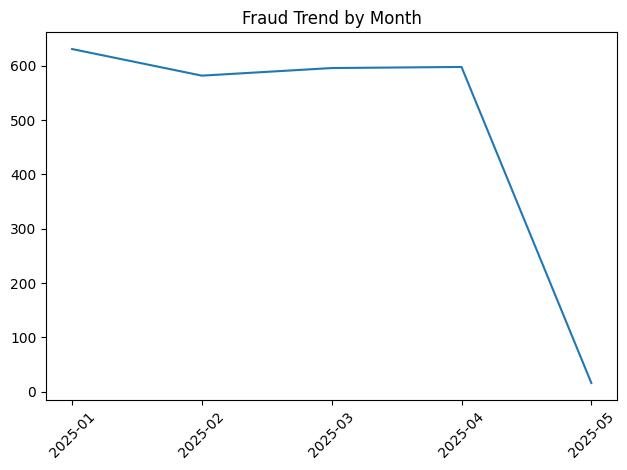

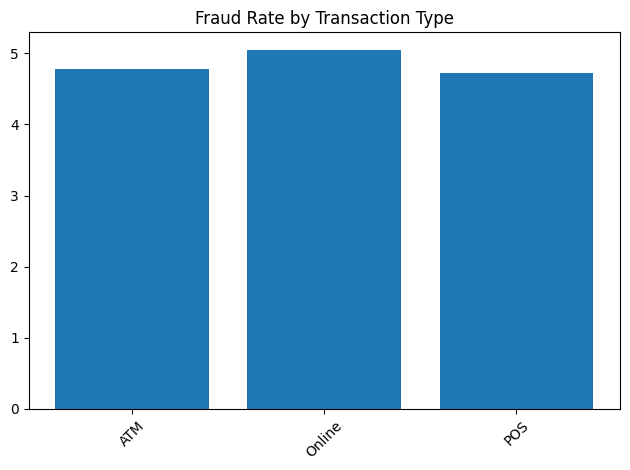

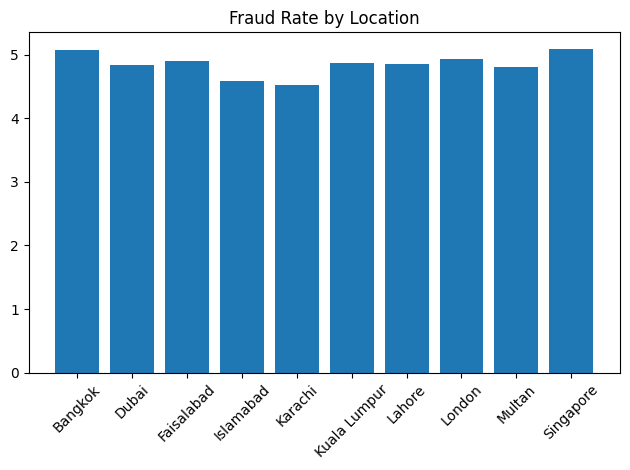

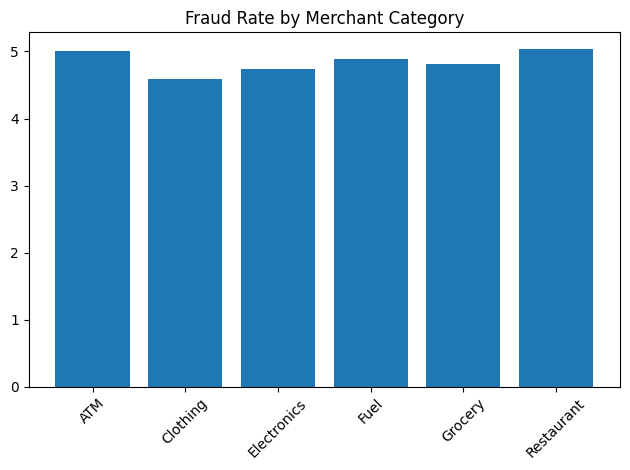

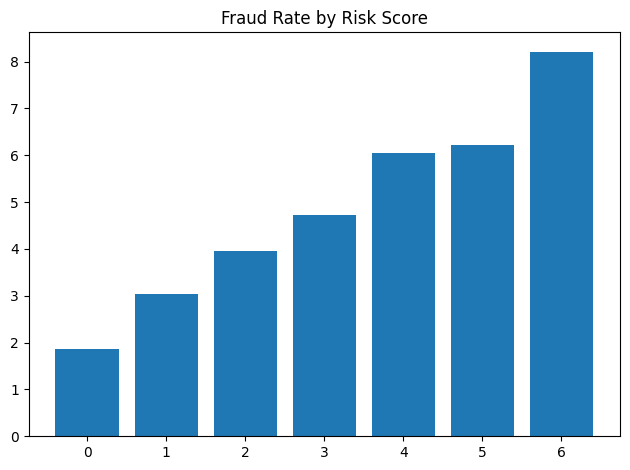

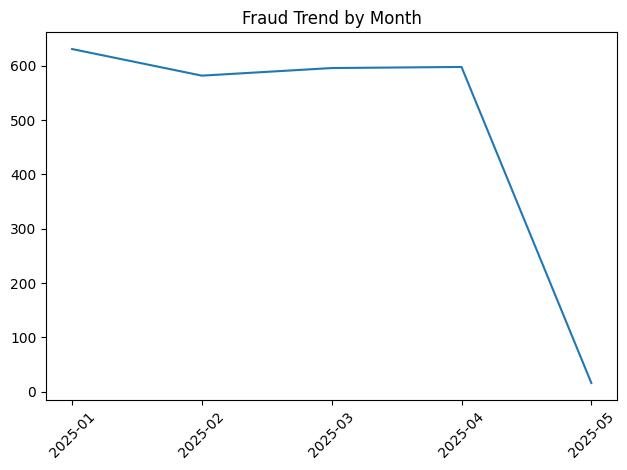

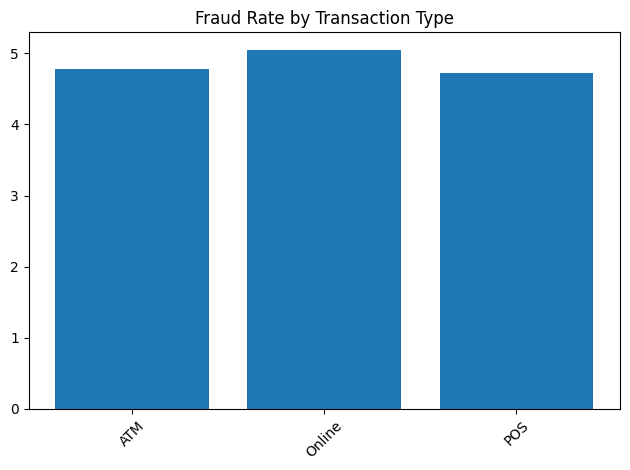

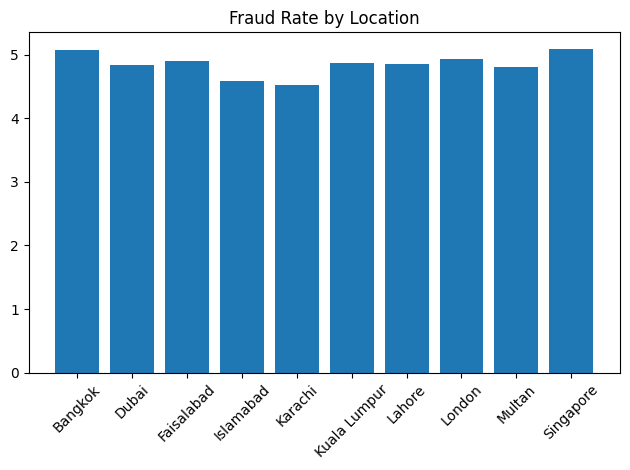


===== TOP RISKY CUSTOMERS =====
       customer_id  total_txn  fraud_count
13305      41045.0          3            3
30057      80610.0          3            2
11841      37568.0          2            2
25722      70345.0          2            2
22638      62997.0          4            2
26458      72076.0          2            2
2125       14975.0          2            2
30219      81043.0          2            2
20633      58316.0          3            2
17710      51398.0          2            2


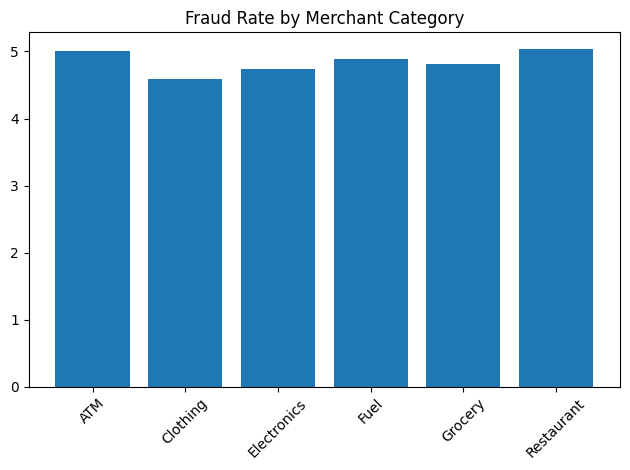

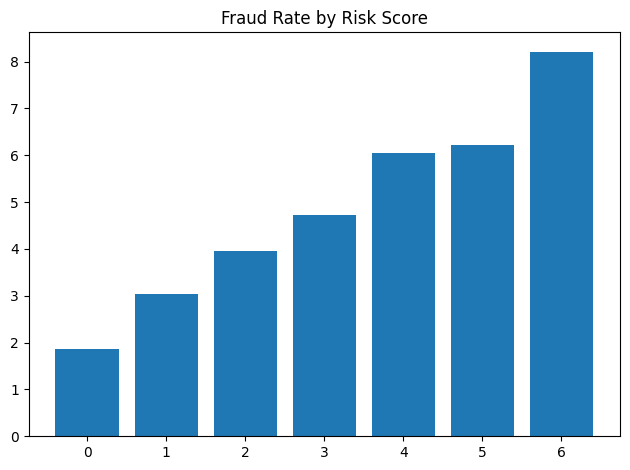

In [161]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
%matplotlib inline

# =============================
# LOAD DATA
# =============================
conn = sqlite3.connect("fraud.db")
df = pd.read_sql("SELECT * FROM transactions", conn)
conn.close()

# =============================
# CLEANING
# =============================
df = df.copy()

df["txn_month"] = pd.to_datetime(df["txn_month"], errors="coerce")
df = df.dropna(subset=["txn_month"])
df["txn_month"] = df["txn_month"].dt.to_period("M").astype(str)

# =============================
# KPI
# =============================
total_txn = len(df)
fraud_count = len(df[df["fraud_label"] == "Fraud"])
fraud_rate = fraud_count / total_txn * 100
avg_amount = df["transaction_amount_in_million"].mean()

print("===== KPI =====")
print("Total Transactions:", total_txn)
print("Fraud Cases:", fraud_count)
print("Fraud Rate (%):", round(fraud_rate, 2))
print("Avg Amount (M):", round(avg_amount, 2))


# =============================
# FRAUD TREND
# =============================
trend = df.groupby("txn_month").agg(
    fraud_count=("fraud_label", lambda x: (x == "Fraud").sum())
).reset_index()

plt.figure()
plt.plot(trend["txn_month"], trend["fraud_count"])
plt.title("Fraud Trend by Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# =============================
# FRAUD BY TRANSACTION TYPE
# =============================
fraud_type = df.groupby("transaction_type").agg(
    total=("fraud_label", "count"),
    fraud=("fraud_label", lambda x: (x == "Fraud").sum())
).reset_index()

fraud_type["fraud_rate"] = fraud_type["fraud"] / fraud_type["total"] * 100

plt.figure()
plt.bar(fraud_type["transaction_type"], fraud_type["fraud_rate"])
plt.title("Fraud Rate by Transaction Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# =============================
# FRAUD BY LOCATION
# =============================
location = df.groupby("transaction_location").agg(
    total=("fraud_label", "count"),
    fraud=("fraud_label", lambda x: (x == "Fraud").sum())
).reset_index()

location["fraud_rate"] = location["fraud"] / location["total"] * 100

plt.figure()
plt.bar(location["transaction_location"], location["fraud_rate"])
plt.title("Fraud Rate by Location")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# =============================
# TOP CUSTOMERS
# =============================
top_customers = df.groupby("customer_id").agg(
    total_txn=("fraud_label", "count"),
    fraud_count=("fraud_label", lambda x: (x == "Fraud").sum())
).reset_index()

top_customers = top_customers[top_customers["fraud_count"] > 0]
top_customers = top_customers.sort_values(by="fraud_count", ascending=False).head(10)

print("\n===== TOP RISKY CUSTOMERS =====")
print(top_customers)


# =============================
# MERCHANT ANALYSIS
# =============================
merchant = df.groupby("merchant_category").agg(
    total=("fraud_label", "count"),
    fraud=("fraud_label", lambda x: (x == "Fraud").sum())
).reset_index()

merchant["fraud_rate"] = merchant["fraud"] / merchant["total"] * 100

plt.figure()
plt.bar(merchant["merchant_category"], merchant["fraud_rate"])
plt.title("Fraud Rate by Merchant Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# =============================
# RISK SCORE DISTRIBUTION
# =============================
risk = df.groupby("risk_score").agg(
    total=("fraud_label", "count"),
    fraud=("fraud_label", lambda x: (x == "Fraud").sum())
).reset_index()

risk["fraud_rate"] = risk["fraud"] / risk["total"] * 100

plt.figure()
plt.bar(risk["risk_score"], risk["fraud_rate"])
plt.title("Fraud Rate by Risk Score")
plt.tight_layout()
plt.show()

C:\Users\Leonardo\AppData\Local\Temp\ipykernel_13344\3272862726.py:103: UserWarning: Glyph 128179 (\N{CREDIT CARD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Leonardo\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128179 (\N{CREDIT CARD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


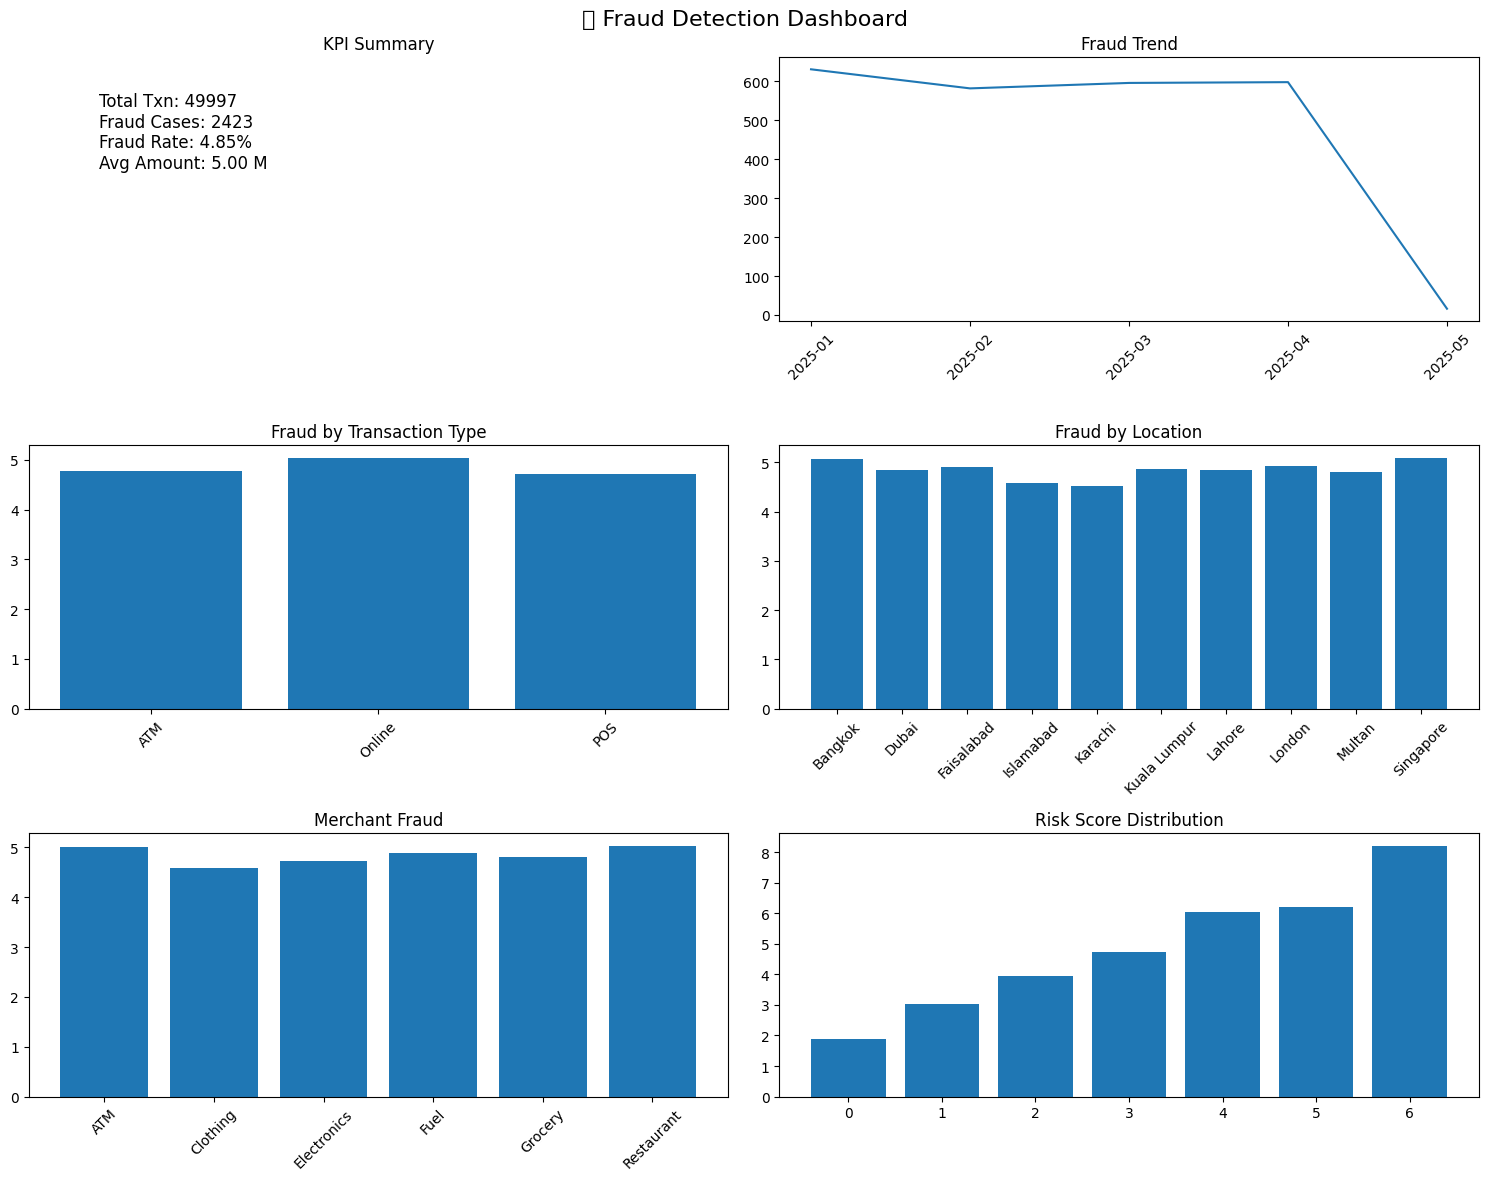

In [163]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# =============================
# LOAD DATA
# =============================
conn = sqlite3.connect("fraud.db")
df = pd.read_sql("SELECT * FROM transactions", conn)
conn.close()

# =============================
# CLEANING
# =============================
df = df.copy()

df["txn_month"] = pd.to_datetime(df["txn_month"], errors="coerce")
df = df.dropna(subset=["txn_month"])
df["txn_month"] = df["txn_month"].dt.to_period("M").astype(str)

# =============================
# KPI
# =============================
total_txn = len(df)
fraud_count = len(df[df["fraud_label"] == "Fraud"])
fraud_rate = fraud_count / total_txn * 100
avg_amount = df["transaction_amount_in_million"].mean()

# =============================
# PREP DATA
# =============================
trend = df.groupby("txn_month").agg(
    fraud_count=("fraud_label", lambda x: (x == "Fraud").sum())
).reset_index()

fraud_type = df.groupby("transaction_type").agg(
    total=("fraud_label", "count"),
    fraud=("fraud_label", lambda x: (x == "Fraud").sum())
).reset_index()
fraud_type["fraud_rate"] = fraud_type["fraud"] / fraud_type["total"] * 100

location = df.groupby("transaction_location").agg(
    total=("fraud_label", "count"),
    fraud=("fraud_label", lambda x: (x == "Fraud").sum())
).reset_index()
location["fraud_rate"] = location["fraud"] / location["total"] * 100

merchant = df.groupby("merchant_category").agg(
    total=("fraud_label", "count"),
    fraud=("fraud_label", lambda x: (x == "Fraud").sum())
).reset_index()
merchant["fraud_rate"] = merchant["fraud"] / merchant["total"] * 100

risk = df.groupby("risk_score").agg(
    total=("fraud_label", "count"),
    fraud=("fraud_label", lambda x: (x == "Fraud").sum())
).reset_index()
risk["fraud_rate"] = risk["fraud"] / risk["total"] * 100

# =============================
# CREATE DASHBOARD (GRID)
# =============================
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

# ===== KPI TEXT =====
fig.suptitle("💳 Fraud Detection Dashboard", fontsize=16)

kpi_text = f"""
Total Txn: {total_txn}
Fraud Cases: {fraud_count}
Fraud Rate: {fraud_rate:.2f}%
Avg Amount: {avg_amount:.2f} M
"""

axes[0,0].text(0.1, 0.5, kpi_text, fontsize=12)
axes[0,0].set_title("KPI Summary")
axes[0,0].axis("off")

# ===== TREND =====
axes[0,1].plot(trend["txn_month"], trend["fraud_count"])
axes[0,1].set_title("Fraud Trend")
axes[0,1].tick_params(axis='x', rotation=45)

# ===== TRANSACTION TYPE =====
axes[1,0].bar(fraud_type["transaction_type"], fraud_type["fraud_rate"])
axes[1,0].set_title("Fraud by Transaction Type")
axes[1,0].tick_params(axis='x', rotation=45)

# ===== LOCATION =====
axes[1,1].bar(location["transaction_location"], location["fraud_rate"])
axes[1,1].set_title("Fraud by Location")
axes[1,1].tick_params(axis='x', rotation=45)

# ===== MERCHANT =====
axes[2,0].bar(merchant["merchant_category"], merchant["fraud_rate"])
axes[2,0].set_title("Merchant Fraud")
axes[2,0].tick_params(axis='x', rotation=45)

# ===== RISK SCORE =====
axes[2,1].bar(risk["risk_score"], risk["fraud_rate"])
axes[2,1].set_title("Risk Score Distribution")

plt.tight_layout()
plt.show()